# Modality, Head-Final IMB, and Case-Marking Analysis

**Load-smoothing hypothesis across 177 UD treebanks (566K sentences)**

This notebook demonstrates the computational methods behind Phases 4-5 of the load-smoothing hypothesis:
- **Phase 4**: Compares spoken vs written LLF (Load-Levelling Factor) across language pairs
- **Phase 5a**: Computes standard and encounter-only IMB (Information-theoretic Memory Burden) for SOV vs SVO treebanks
- **Phase 5b**: Tests case-richness/LLF correlation in SOV languages
- **Phase 5c**: DOM (Differential Object Marking) analysis across treebanks

Core algorithms are demonstrated on sample sentences, then pre-computed results from the full analysis are visualized.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All imported packages are pre-installed on Colab; install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')
    _pip('scipy==1.15.3')       # Colab: 1.16.3 (requires Python 3.11+)
    _pip('statsmodels==0.14.6')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import json
import math
import os
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-e4150b-head-directionality-dependent-temporal-d/main/experiment_iter2_modality_head_f/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with keys: {list(data.keys())}")
print(f"Sample sentences: {list(data['sample_sentences'].keys())}")
print(f"Phase 4 pairs: {len(data['phase4_modality']['pairs'])}")
print(f"Phase 5a treebanks: {len(data['phase5a_head_final']['treebanks'])}")
print(f"Phase 5b scatter points: {len(data['phase5b_case_richness']['scatter'])}")
print(f"Phase 5c DOM treebanks: {len(data['phase5c_dom']['per_treebank'])}")

Loaded data with keys: ['metadata', 'sample_sentences', 'phase4_modality', 'phase5a_head_final', 'phase5b_case_richness', 'phase5c_dom', 'pilot_validation']
Sample sentences: ['head_initial_tree', 'head_final_tree', 'tree_a', 'tree_b', 'with_disfluency', 'longer_sov', 'longer_svo']
Phase 4 pairs: 6
Phase 5a treebanks: 177
Phase 5b scatter points: 51
Phase 5c DOM treebanks: 33


## Configuration

Tunable parameters for the demo. Bootstrap iterations are set low for speed; the full analysis uses 10,000.

In [5]:
# --- Config ---
# Bootstrap iterations for Cohen's d confidence intervals
N_BOOT = 10000        # Full analysis value
# Confidence interval level
CI_LEVEL = 0.95
# Disfluency deprels to exclude in spoken data
DISFLUENCY_DEPRELS = frozenset({"reparandum", "discourse:filler"})
# Cost function exponents for IMB
COST_ALPHAS = [1.0, 1.2, 1.5, 2.0, 3.0]

## Core IMB Computation

The **IMB (Information-theoretic Memory Burden)** profile tracks how many open dependencies each word position must hold in memory during left-to-right processing. The **LLF (Load-Levelling Factor)** measures how evenly the memory load is distributed across a sentence.

- **Standard mode**: every dependency contributes to the profile
- **Encounter-only mode**: head-final dependencies (where head hasn't been seen yet) are zeroed out

In [6]:
def compute_imb_profile(
    heads: list,
    deprels: list,
    *,
    exclude_disfluency: bool = False,
    encounter_only: bool = False,
) -> list:
    """Compute age-weighted IMB profile from 1-indexed heads (0 = root).

    Standard mode: every dependency contributes.
    Encounter-only mode: head-final deps (head right of dependent) are zeroed
    out because the head has not yet been encountered during left-to-right
    processing.
    """
    n = len(heads)
    if n == 0:
        return []

    opens = []
    closes = []

    for i in range(n):
        h = heads[i]
        if h == 0:
            continue
        if exclude_disfluency and deprels[i] in DISFLUENCY_DEPRELS:
            continue
        dep_pos = i + 1   # 1-indexed
        head_pos = h       # 1-indexed

        if encounter_only and head_pos > dep_pos:
            # head-final: head not yet seen -> skip
            continue

        opens.append(min(dep_pos, head_pos))
        closes.append(max(dep_pos, head_pos))

    if not opens:
        return [0.0] * n

    # Vectorised computation
    ops = np.array(opens, dtype=np.int32)
    cls = np.array(closes, dtype=np.int32)
    j_pos = np.arange(1, n + 1, dtype=np.int32)[:, None]   # (n, 1)

    mask = (ops[None, :] <= j_pos) & (j_pos <= cls[None, :])  # (n, d)
    ages = j_pos - ops[None, :]                                # (n, d)

    imb = np.sum(ages * mask, axis=1).astype(float)
    return imb.tolist()


def compute_llf_metrics(imb_profile: list, dd_list: list) -> dict:
    """Derive LLF and related metrics from an IMB profile."""
    n = len(imb_profile)
    if n == 0:
        return {"max_imb": 0.0, "mean_imb": 0.0, "llf": 0.0,
                "total_imb": 0.0, "total_imb_formula": 0.0, "costs": {}}

    max_imb = float(max(imb_profile))
    total_imb = float(sum(imb_profile))
    mean_imb = total_imb / n
    llf = mean_imb / max_imb if max_imb > 0 else 0.0

    costs = {str(a): sum(v ** a for v in imb_profile) for a in COST_ALPHAS}
    total_imb_formula = sum(d * (d + 1) / 2.0 for d in dd_list)

    return {
        "max_imb": max_imb,
        "mean_imb": mean_imb,
        "llf": llf,
        "total_imb": total_imb,
        "total_imb_formula": total_imb_formula,
        "costs": costs,
    }


def compute_head_final_proportion(heads: list) -> float:
    """Fraction of dependencies where head is to the right of dependent."""
    n_deps = 0
    n_hf = 0
    for i, h in enumerate(heads):
        if h == 0:
            continue
        n_deps += 1
        if h > i + 1:
            n_hf += 1
    return n_hf / n_deps if n_deps > 0 else 0.0

print("Core functions defined.")

Core functions defined.


## Statistical Helpers

Cohen's d with bootstrap confidence intervals, OLS residualization for controlling covariates, and partial correlation.

In [7]:
def cohens_d(g1, g2):
    """Compute Cohen's d with pooled SD."""
    n1, n2 = len(g1), len(g2)
    if n1 < 2 or n2 < 2:
        return float("nan")
    var1 = float(np.var(g1, ddof=1))
    var2 = float(np.var(g2, ddof=1))
    pooled_sd = math.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    if pooled_sd < 1e-15:
        return 0.0
    return float((np.mean(g1) - np.mean(g2)) / pooled_sd)


def bootstrap_cohens_d_ci(g1, g2, n_boot=None, ci=None):
    """Bootstrap CI for Cohen's d."""
    if n_boot is None:
        n_boot = N_BOOT
    if ci is None:
        ci = CI_LEVEL
    rng = np.random.RandomState(42)
    ds = np.empty(n_boot)
    n1, n2 = len(g1), len(g2)
    for i in range(n_boot):
        s1 = g1[rng.randint(0, n1, n1)]
        s2 = g2[rng.randint(0, n2, n2)]
        v1 = float(np.var(s1, ddof=1))
        v2 = float(np.var(s2, ddof=1))
        psd = math.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
        ds[i] = (np.mean(s1) - np.mean(s2)) / psd if psd > 1e-15 else 0.0
    alpha = (1 - ci) / 2
    return [float(np.percentile(ds, alpha * 100)),
            float(np.percentile(ds, (1 - alpha) * 100))]


def residualize_ols(y, X):
    """OLS residualisation: y ~ X -> residuals."""
    try:
        col_var = np.var(X, axis=0)
        good = col_var > 1e-10
        if not np.any(good):
            return y - np.mean(y)
        X_clean = X[:, good]
        X_const = sm.add_constant(X_clean)
        model = sm.OLS(y, X_const).fit()
        return model.resid
    except Exception:
        return y - np.mean(y)

print("Statistical helpers defined.")

Statistical helpers defined.


## Pilot Validation: Micro-Tests on Sample Trees

Verify the IMB computation on hardcoded trees with known expected outputs. This validates correctness before scaling to real treebank data.

In [8]:
# ---- Micro-validation on hardcoded trees ----
samples = data["sample_sentences"]

# Tree A: right-branching chain
ta = samples["tree_a"]
imb_a = compute_imb_profile(ta["heads"], ta["deprels"])
m_a = compute_llf_metrics(imb_a, ta["dd_list"])
print(f"Tree A IMB:  {imb_a}  expected {ta['expected_imb']}  -> {'PASS' if imb_a == ta['expected_imb'] else 'FAIL'}")
print(f"Tree A LLF:  {m_a['llf']:.6f}  expected {ta['expected_llf']:.6f}  -> {'PASS' if abs(m_a['llf'] - ta['expected_llf']) < 1e-4 else 'FAIL'}")
print(f"Tree A identity: total_imb={m_a['total_imb']} == formula={m_a['total_imb_formula']}  -> {'PASS' if abs(m_a['total_imb'] - m_a['total_imb_formula']) < 1e-6 else 'FAIL'}")

# Tree B: balanced
tb = samples["tree_b"]
imb_b = compute_imb_profile(tb["heads"], tb["deprels"])
m_b = compute_llf_metrics(imb_b, tb["dd_list"])
print(f"\nTree B IMB:  {imb_b}  expected {tb['expected_imb']}  -> {'PASS' if imb_b == tb['expected_imb'] else 'FAIL'}")
print(f"Tree B LLF:  {m_b['llf']:.6f}  expected {tb['expected_llf']:.6f}  -> {'PASS' if abs(m_b['llf'] - tb['expected_llf']) < 1e-4 else 'FAIL'}")

# Head-final tree: encounter-only should be all zeros
hf = samples["head_final_tree"]
std_hf = compute_imb_profile(hf["heads"], hf["deprels"], encounter_only=False)
enc_hf = compute_imb_profile(hf["heads"], hf["deprels"], encounter_only=True)
ok_hf = all(v == 0.0 for v in enc_hf) and any(v > 0 for v in std_hf)
print(f"\nHead-final: std={std_hf} enc={enc_hf}  -> {'PASS' if ok_hf else 'FAIL'}")

# Head-initial tree: encounter-only should equal standard
hi = samples["head_initial_tree"]
std_hi = compute_imb_profile(hi["heads"], hi["deprels"], encounter_only=False)
enc_hi = compute_imb_profile(hi["heads"], hi["deprels"], encounter_only=True)
ok_hi = std_hi == enc_hi
print(f"Head-initial: std={std_hi} enc={enc_hi}  -> {'PASS' if ok_hi else 'FAIL'}")

# Disfluency exclusion
df = samples["with_disfluency"]
no_ex = compute_imb_profile(df["heads"], df["deprels"], exclude_disfluency=False)
ex_df = compute_imb_profile(df["heads"], df["deprels"], exclude_disfluency=True)
ok_df = no_ex != ex_df
print(f"Disfluency: no_excl={no_ex} excl={ex_df}  -> {'PASS' if ok_df else 'FAIL'}")

# Head-final proportion comparison
hf_prop = compute_head_final_proportion(hf["heads"])
hi_prop = compute_head_final_proportion(hi["heads"])
print(f"\nHead-final proportion: head-final tree={hf_prop:.2f}, head-initial tree={hi_prop:.2f}")

Tree A IMB:  [0.0, 1.0, 2.0, 3.0, 2.0]  expected [0.0, 1.0, 2.0, 3.0, 2.0]  -> PASS
Tree A LLF:  0.533333  expected 0.533333  -> PASS
Tree A identity: total_imb=8.0 == formula=8.0  -> PASS

Tree B IMB:  [0.0, 2.0, 2.0, 2.0, 2.0]  expected [0.0, 2.0, 2.0, 2.0, 2.0]  -> PASS
Tree B LLF:  0.800000  expected 0.800000  -> PASS

Head-final: std=[0.0, 1.0, 3.0, 6.0, 10.0] enc=[0.0, 0.0, 0.0, 0.0, 0.0]  -> PASS
Head-initial: std=[0.0, 4.0, 6.0, 6.0, 4.0] enc=[0.0, 4.0, 6.0, 6.0, 4.0]  -> PASS
Disfluency: no_excl=[0.0, 2.0, 2.0, 1.0] excl=[0.0, 1.0, 0.0, 1.0]  -> PASS

Head-final proportion: head-final tree=1.00, head-initial tree=0.00


## IMB Profile Comparison: Standard vs Encounter-Only

Compare standard and encounter-only IMB profiles on SOV-like vs SVO-like sample sentences. In head-final (SOV) trees, encounter-only mode dramatically reduces the memory burden because many dependencies point to heads not yet encountered.

In [9]:
# Compare standard vs encounter-only IMB on SOV-like and SVO-like trees
for name in ["head_final_tree", "head_initial_tree", "longer_sov", "longer_svo"]:
    s = samples[name]
    std = compute_imb_profile(s["heads"], s["deprels"], encounter_only=False)
    enc = compute_imb_profile(s["heads"], s["deprels"], encounter_only=True)
    std_m = compute_llf_metrics(std, s.get("dd_list", []))
    enc_m = compute_llf_metrics(enc, s.get("dd_list", []))
    hf = compute_head_final_proportion(s["heads"])
    delta = std_m["llf"] - enc_m["llf"]
    print(f"{name:20s}  head-final={hf:.2f}  std_LLF={std_m['llf']:.4f}  "
          f"enc_LLF={enc_m['llf']:.4f}  delta={delta:+.4f}  "
          f"max_imb: {std_m['max_imb']:.0f}->{enc_m['max_imb']:.0f}")

head_final_tree       head-final=1.00  std_LLF=0.4000  enc_LLF=0.0000  delta=+0.4000  max_imb: 10->0
head_initial_tree     head-final=0.00  std_LLF=0.6667  enc_LLF=0.6667  delta=+0.0000  max_imb: 6->6
longer_sov            head-final=0.71  std_LLF=0.3889  enc_LLF=0.4444  delta=-0.0556  max_imb: 6->3
longer_svo            head-final=0.00  std_LLF=0.5185  enc_LLF=0.5185  delta=+0.0000  max_imb: 6->6


## Phase 4: Spoken vs Written Modality Comparison

Compares residualized LLF between spoken and written corpora across 6 language pairs. The analysis uses OLS to control for sentence length, tree depth, and dependency distance, then applies Welch's t-test with Bonferroni correction.

In [10]:
# Phase 4: Display pre-computed modality comparison results
p4 = data["phase4_modality"]
print("Phase 4: Spoken vs Written LLF Comparison")
print("=" * 70)
print(f"{'Pair':<12} {'Language':<18} {'N_sp':>7} {'N_wr':>7} {'LLF_sp':>8} {'LLF_wr':>8} {'d':>8} {'p':>12} {'Sp>Wr':>6}")
print("-" * 70)
for pair in p4["pairs"]:
    lang = pair["lang"][:16]
    d_val = pair.get("residual_llf_cohens_d")
    p_val = pair.get("residual_llf_p")
    sp_h = pair.get("spoken_higher")
    d_str = f"{d_val:+.4f}" if d_val is not None else "N/A"
    p_str = f"{p_val:.2e}" if p_val is not None else "N/A"
    sp_str = "Yes" if sp_h else "No" if sp_h is not None else "N/A"
    print(f"{pair['pair_id']:<12} {lang:<18} {pair['n_spoken']:>7} {pair['n_written']:>7} "
          f"{pair.get('mean_llf_spoken', 0):>8.4f} {pair.get('mean_llf_written', 0):>8.4f} "
          f"{d_str:>8} {p_str:>12} {sp_str:>6}")

agg = p4["aggregate"]
print(f"\nAggregate: {agg['n_spoken_higher']}/{agg['n_pairs']} pairs spoken > written")
print(f"Mean Cohen's d: {agg['mean_cohens_d']:.4f}")
print(f"Significant at Bonferroni p<0.01: {agg['n_significant']}/{agg['n_pairs']}")

Phase 4: Spoken vs Written LLF Comparison
Pair         Language              N_sp    N_wr   LLF_sp   LLF_wr        d            p  Sp>Wr
----------------------------------------------------------------------
sl           Slovenian             3290   10000   0.4280   0.4315  +0.0314     1.19e-01    Yes
fr           French                3570   10000   0.4187   0.4677  -0.5306    5.00e-151     No
it           Italian                310   10000   0.4495   0.4679  -0.1808     1.46e-03     No
tr           Turkish               3099    5589   0.4185   0.3889  +0.1206     1.10e-07    Yes
en           English              13071   10000   0.4517   0.4473  +0.0266     4.70e-02    Yes
en_extra     English (extra)        922   10000   0.4227   0.4473  -0.2432     2.35e-14     No

Aggregate: 3/6 pairs spoken > written
Mean Cohen's d: -0.1293
Significant at Bonferroni p<0.01: 4/6


## Phase 5a: Head-Final Language Effects (SOV vs SVO)

SOV languages have more head-final dependencies, so encounter-only IMB should be much lower than standard IMB. The `llf_delta` (standard LLF minus encounter-only LLF) should be larger for SOV than SVO treebanks.

In [11]:
# Phase 5a: Head-final effects from pre-computed data
p5a = data["phase5a_head_final"]
tbs = p5a["treebanks"]

sov_tbs = [t for t in tbs if t["word_order"] == "SOV"]
svo_tbs = [t for t in tbs if t["word_order"] == "SVO"]

sov_deltas = np.array([t["llf_delta"] for t in sov_tbs])
svo_deltas = np.array([t["llf_delta"] for t in svo_tbs])

# Compute comparison statistics
_, p_cmp = stats.ttest_ind(sov_deltas, svo_deltas, equal_var=False)
d_cmp = cohens_d(sov_deltas, svo_deltas)

print("Phase 5a: SOV vs SVO LLF Delta")
print("=" * 50)
print(f"SOV treebanks: {len(sov_tbs)}, mean llf_delta = {np.mean(sov_deltas):.4f} +/- {np.std(sov_deltas):.4f}")
print(f"SVO treebanks: {len(svo_tbs)}, mean llf_delta = {np.mean(svo_deltas):.4f} +/- {np.std(svo_deltas):.4f}")
print(f"Cohen's d = {d_cmp:.4f}, p = {p_cmp:.2e}")
print(f"SOV has dramatically larger llf_delta: {'Yes' if np.mean(sov_deltas) > np.mean(svo_deltas) else 'No'}")

# Head-final proportion correlation
all_hf = np.array([t["proportion_head_final"] for t in tbs])
all_dl = np.array([t["llf_delta"] for t in tbs])
pr_, pp_ = pearsonr(all_hf, all_dl)
sr_, sp_ = spearmanr(all_hf, all_dl)
print(f"\nHead-final proportion vs llf_delta:")
print(f"  Pearson r = {pr_:.4f}, p = {pp_:.2e}")
print(f"  Spearman r = {sr_:.4f}, p = {sp_:.2e}")

Phase 5a: SOV vs SVO LLF Delta
SOV treebanks: 51, mean llf_delta = 0.1009 +/- 0.0674
SVO treebanks: 126, mean llf_delta = -0.0033 +/- 0.0208
Cohen's d = 2.5766, p = 5.45e-15
SOV has dramatically larger llf_delta: Yes

Head-final proportion vs llf_delta:
  Pearson r = 0.5008, p = 1.27e-12
  Spearman r = 0.2582, p = 5.22e-04


## Phase 5b: Case-Marking Richness and LLF

Tests whether morphological case-richness correlates with LLF in SOV languages. The hypothesis is that richer case marking might allow freer word order and affect memory load distribution.

In [12]:
# Phase 5b: Case richness correlation from pre-computed data
p5b = data["phase5b_case_richness"]
scatter = p5b["scatter"]

cr = np.array([d["case_richness_count"] for d in scatter], dtype=float)
llf = np.array([d["mean_llf_standard"] for d in scatter])

pr, pp = pearsonr(cr, llf)
sr, sp_ = spearmanr(cr, llf)

print("Phase 5b: Case-Richness vs LLF in SOV Languages")
print("=" * 50)
print(f"N SOV treebanks: {len(scatter)}")
print(f"Case richness count range: {int(cr.min())} - {int(cr.max())}")
print(f"Pearson r = {pr:.4f}, p = {pp:.4f}")
print(f"Spearman r = {sr:.4f}, p = {sp_:.4f}")
print(f"Significant correlation: {'Yes' if pp < 0.05 else 'No (as expected)'}")

Phase 5b: Case-Richness vs LLF in SOV Languages
N SOV treebanks: 51
Case richness count range: 0 - 15
Pearson r = -0.0474, p = 0.7412
Spearman r = -0.1153, p = 0.4204
Significant correlation: No (as expected)


## Phase 5c: Differential Object Marking (DOM)

Within-language comparison of case-marked vs unmarked object sentences. Tests whether case-marking on objects affects LLF distribution.

In [13]:
# Phase 5c: DOM analysis from pre-computed data
p5c = data["phase5c_dom"]
dom_tbs = p5c["per_treebank"]
suf = [t for t in dom_tbs if t["sufficient_data"]]

print("Phase 5c: Differential Object Marking")
print("=" * 70)
print(f"{'Treebank':<16} {'Language':<14} {'N_cm':>6} {'N_um':>6} {'d':>8} {'p':>12} {'Direction':<20}")
print("-" * 70)
for t in suf:
    d_str = f"{t['cohens_d']:+.4f}" if t['cohens_d'] is not None else "N/A"
    p_str = f"{t['p']:.2e}" if t['p'] is not None else "N/A"
    dir_str = t.get("direction", "N/A")
    print(f"{t['tb_id']:<16} {t['lang'][:12]:<14} {t['n_case_marked']:>6} {t['n_unmarked']:>6} "
          f"{d_str:>8} {p_str:>12} {dir_str:<20}")

n_pos = sum(1 for t in suf if t.get("direction") == "case_marked_higher")
agg = p5c["aggregate"]
print(f"\n{n_pos}/{len(suf)} treebanks show case-marked higher LLF")
if agg.get("mixed_effects_coefficient") is not None:
    print(f"Mixed-effects coefficient: {agg['mixed_effects_coefficient']:.4f} (p={agg['mixed_effects_p']:.4f})")

Phase 5c: Differential Object Marking
Treebank         Language         N_cm   N_um        d            p Direction           
----------------------------------------------------------------------
es_ancora        Spanish           269   6805  -0.1908     6.65e-03 unmarked_higher     
es_coser         Spanish            42    114  -0.4612     9.69e-03 unmarked_higher     
es_gsd           Spanish           257   4862  -0.3476     3.54e-07 unmarked_higher     
es_pud           Spanish            26    510  +0.3441     1.23e-01 case_marked_higher  
he_htb           Modern Hebre       23   2760  -0.0839     7.43e-01 unmarked_higher     
he_iahltwiki     Modern Hebre       18   2160  -0.1343     6.21e-01 unmarked_higher     
hi_hdtb          Hindi            4532    694  +0.1862     1.08e-06 case_marked_higher  
hi_pud           Hindi             720     29  -0.0325     8.77e-01 unmarked_higher     
ko_pud           Korean            538     51  -0.1054     4.72e-01 unmarked_higher     
r

## Visualization

Four-panel summary of key results across all phases.

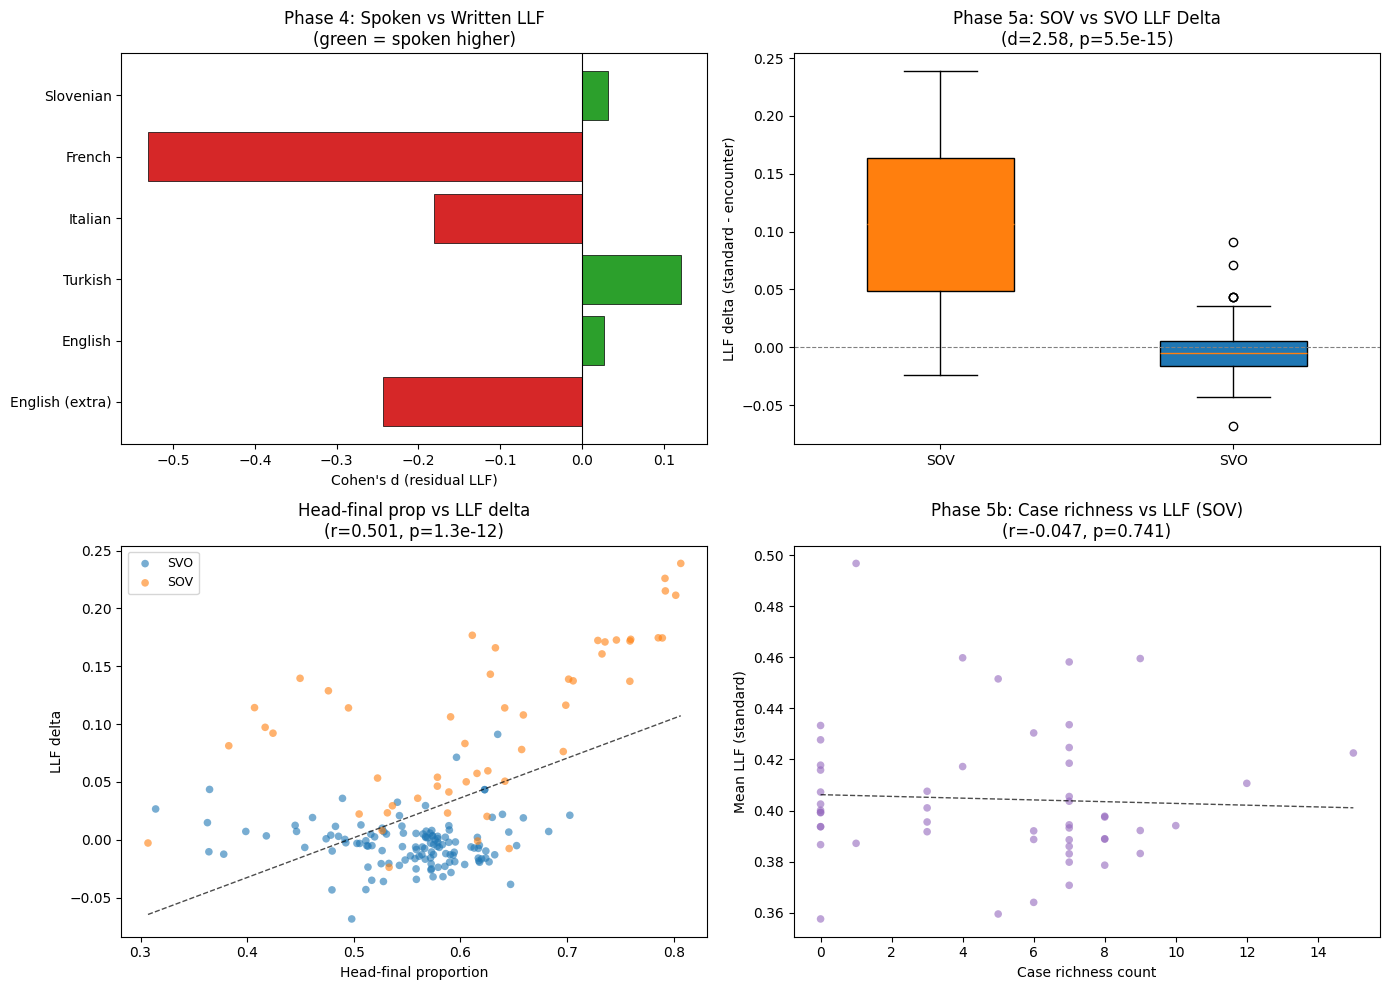

Saved results_summary.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Phase 4 — Modality Cohen's d ---
ax = axes[0, 0]
pairs = p4["pairs"]
langs = [p["lang"] for p in pairs]
ds = [p.get("residual_llf_cohens_d", 0) or 0 for p in pairs]
colors = ["#2ca02c" if p.get("spoken_higher") else "#d62728" for p in pairs]
bars = ax.barh(langs, ds, color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Cohen's d (residual LLF)")
ax.set_title("Phase 4: Spoken vs Written LLF\n(green = spoken higher)")
ax.invert_yaxis()

# --- Panel 2: Phase 5a — SOV vs SVO llf_delta distributions ---
ax = axes[0, 1]
bp = ax.boxplot([sov_deltas, svo_deltas], tick_labels=["SOV", "SVO"],
                patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("#ff7f0e")
bp["boxes"][1].set_facecolor("#1f77b4")
ax.set_ylabel("LLF delta (standard - encounter)")
ax.set_title(f"Phase 5a: SOV vs SVO LLF Delta\n(d={d_cmp:.2f}, p={p_cmp:.1e})")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

# --- Panel 3: Phase 5a — Head-final proportion vs llf_delta scatter ---
ax = axes[1, 0]
sov_hf = [t["proportion_head_final"] for t in sov_tbs]
svo_hf = [t["proportion_head_final"] for t in svo_tbs]
sov_dl = [t["llf_delta"] for t in sov_tbs]
svo_dl = [t["llf_delta"] for t in svo_tbs]
ax.scatter(svo_hf, svo_dl, c="#1f77b4", alpha=0.6, s=30, label="SVO", edgecolors="none")
ax.scatter(sov_hf, sov_dl, c="#ff7f0e", alpha=0.6, s=30, label="SOV", edgecolors="none")
# Fit line
z = np.polyfit(all_hf, all_dl, 1)
x_line = np.linspace(all_hf.min(), all_hf.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), "k--", linewidth=1, alpha=0.7)
ax.set_xlabel("Head-final proportion")
ax.set_ylabel("LLF delta")
ax.set_title(f"Head-final prop vs LLF delta\n(r={pr_:.3f}, p={pp_:.1e})")
ax.legend(fontsize=9)

# --- Panel 4: Phase 5b — Case richness vs LLF scatter ---
ax = axes[1, 1]
ax.scatter(cr, llf, c="#9467bd", alpha=0.6, s=30, edgecolors="none")
if len(cr) > 2:
    z2 = np.polyfit(cr, llf, 1)
    x2 = np.linspace(cr.min(), cr.max(), 100)
    ax.plot(x2, np.polyval(z2, x2), "k--", linewidth=1, alpha=0.7)
ax.set_xlabel("Case richness count")
ax.set_ylabel("Mean LLF (standard)")
ax.set_title(f"Phase 5b: Case richness vs LLF (SOV)\n(r={pr:.3f}, p={pp:.3f})")

plt.tight_layout()
plt.savefig("results_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved results_summary.png")